In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

In [21]:
# Training data (similar to your plot)
X = np.array([
    [8, 4], [9, 2], [9, 1.5], [10, 1], [11, 0], [12, 1.5],
    [8, 5], [9, 5.5], [9.5, 5], [10, 4.5], [10.5, 2.5]
])

y = np.array([
    0, 0, 0, 0, 0, 0,   # class 0 (blue)
    1, 1, 1, 1, 1       # class 1 (red)
])

In [22]:
# Create model (try k = 1, 3, 5)
k = 3
model = KNeighborsClassifier(n_neighbors=k)
model.fit(X, y)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [30]:
# Test points (stars)
test_points = np.array([
    [8, 4],
    [10, 3],
    [11, 0]
])
predictions = model.predict(test_points)
predictions

array([1, 1, 0])

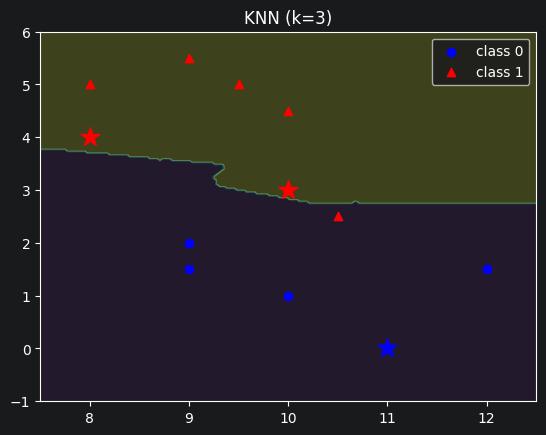

In [24]:
# ---- Decision boundary ----
xx, yy = np.meshgrid(
    np.linspace(7.5, 12.5, 200),
    np.linspace(-1, 6, 200)
)

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.2)

# ---- Plot training data ----
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1],
            color='blue', label='class 0')

plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1],
            color='red', marker='^', label='class 1')

# ---- Plot test points ----
for i, point in enumerate(test_points):
    color = 'blue' if predictions[i] == 0 else 'red'
    plt.scatter(point[0], point[1],
                color=color, marker='*', s=200)

plt.legend()
plt.title(f"KNN (k={k})")
plt.show()

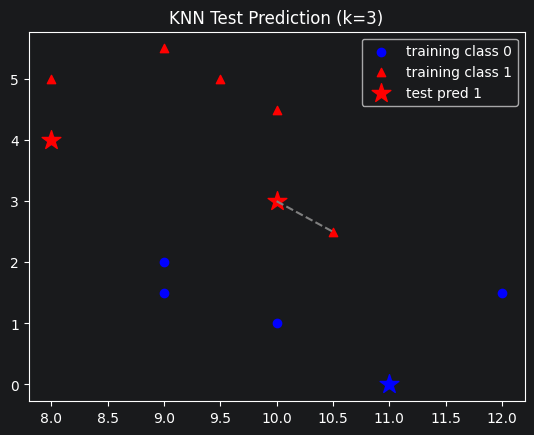

In [25]:
# ---- Plot training data ----
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1],
            color='blue', label='training class 0')

plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1],
            color='red', marker='^', label='training class 1')

# ---- Plot test points + neighbors ----
distances, indices = model.kneighbors(test_points)

for i, point in enumerate(test_points):
    pred = predictions[i]
    neighbor_idx = indices[i][0]
    neighbor = X[neighbor_idx]

    # Star (prediction)
    color = 'blue' if pred == 0 else 'red'
    plt.scatter(point[0], point[1],
                color=color, marker='*', s=200,
                label=f'test pred {pred}' if i == 0 else "")

    # Line to nearest neighbor
    plt.plot([point[0], neighbor[0]],
             [point[1], neighbor[1]],
             color='gray', linestyle='--')

# Avoid duplicate legend labels
handles, labels = plt.gca().get_legend_handles_labels()
unique = dict(zip(labels, handles))
plt.legend(unique.values(), unique.keys())

plt.title(f"KNN Test Prediction (k={k})")
plt.show()

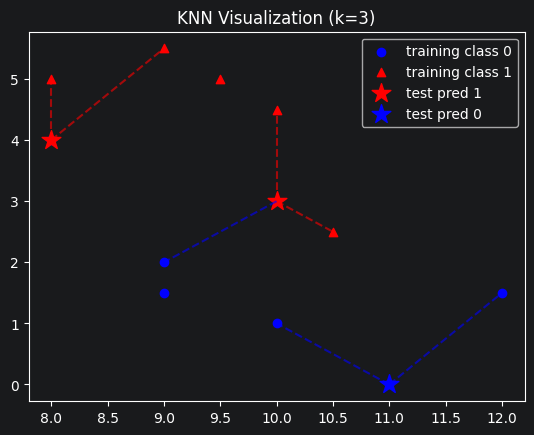

In [33]:
distances, indices = model.kneighbors(test_points)

# ---- Plot training data ----
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1],
            color='blue', label='training class 0')

plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1],
            color='red', marker='^', label='training class 1')

# ---- Plot test points + neighbors ----
for i, point in enumerate(test_points):
    pred = predictions[i]

    # Star for prediction
    if pred == 0:
        plt.scatter(point[0], point[1],
                    color='blue', marker='*', s=200,
                    label='test pred 0')
    else:
        plt.scatter(point[0], point[1],
                    color='red', marker='*', s=200,
                    label='test pred 1')

    # Draw neighbors
    for neighbor_idx in indices[i]:
        neighbor = X[neighbor_idx]
        neighbor_class = y[neighbor_idx]

        line_color = 'blue' if neighbor_class == 0 else 'red'

        plt.plot([point[0], neighbor[0]],
                 [point[1], neighbor[1]],
                 color=line_color,
                 linestyle='--',
                 alpha=0.6)

# ---- Clean legend (remove duplicates) ----
handles, labels = plt.gca().get_legend_handles_labels()
unique = dict(zip(labels, handles))
plt.legend(unique.values(), unique.keys())

plt.title(f"KNN Visualization (k={k})")
plt.show()

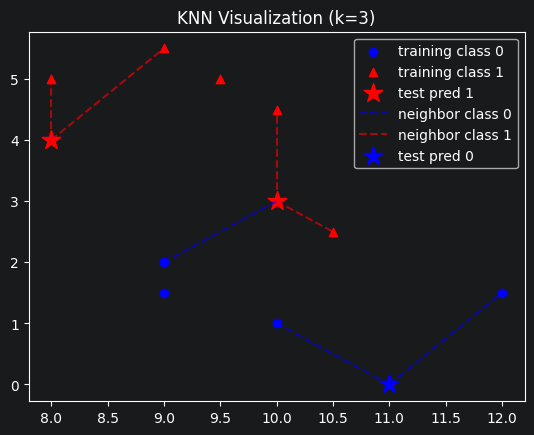

In [28]:
distances, indices = model.kneighbors(test_points)

# ---- Plot training data ----
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1],
            color='blue', label='training class 0')

plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1],
            color='red', marker='^', label='training class 1')

# Track legend labels
added_pred0 = False
added_pred1 = False
added_neighbor0 = False
added_neighbor1 = False

for i, point in enumerate(test_points):
    pred = predictions[i]

    # ---- Plot test point (star) ----
    if pred == 0:
        plt.scatter(point[0], point[1],
                    color='blue', marker='*', s=200,
                    label='test pred 0' if not added_pred0 else "")
        added_pred0 = True
    else:
        plt.scatter(point[0], point[1],
                    color='red', marker='*', s=200,
                    label='test pred 1' if not added_pred1 else "")
        added_pred1 = True

    # ---- Draw neighbors ----
    for neighbor_idx in indices[i]:
        neighbor = X[neighbor_idx]
        neighbor_class = y[neighbor_idx]

        if neighbor_class == 0:
            plt.plot([point[0], neighbor[0]],
                     [point[1], neighbor[1]],
                     color='blue', linestyle='--', alpha=0.6,
                     label='neighbor class 0' if not added_neighbor0 else "")
            added_neighbor0 = True
        else:
            plt.plot([point[0], neighbor[0]],
                     [point[1], neighbor[1]],
                     color='red', linestyle='--', alpha=0.6,
                     label='neighbor class 1' if not added_neighbor1 else "")
            added_neighbor1 = True

# Legend (no duplicates now)
plt.legend()
plt.title(f"KNN Visualization (k={k})")
plt.show()